# **Notebook for EDA Work done for Project**
by Jack Phelan

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Data Quality Assessment](#data-quality-assessment)
3. [Statistical Summary of Dataset](#statistical-summary-of-dataset)
4. [Univariate Analysis](#univariate-analysis)
5. [Bivariate Analysis](#bivariate-analysis)

In [29]:
# imports
import sys

sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scripts.plot_utils import (
    set_theme,
    plot_grid,
    plot_barplot,
    plot_barplot_grid,
    plot_histogram,
    plot_numeric_x_numeric_grid,
    plot_numeric_x_across_categories_grid,
    plot_all_numeric_by_base_category_grid,
    plot_categorical_x_categorical_grid,
)

In [ ]:
raw_df = pd.read_csv(
    "../data/raw/healthcare_readmissions_dataset_train.csv",
    keep_default_na=False,
    na_values=[""],
)

In [13]:
raw_df.head()

,PatientID,Age,Gender,Ethnicity,Hospital ID,Height (m),Smoker,BMI,Weight (kg),Adjusted Weight (kg),Has Diabetes,Has Hypertension,Exercise Frequency,Diet Type,Number of Prior Visits,Medications Prescribed,Length of Stay,Type of Treatment,Readmission within 30 Days
0,1000000,23,Female,African American,Hosp2,1.6,False,25.0,64.0,63.283346,0,0,Regular,High-fat,3.0,3.0,0,None,0
1,1000002,56,Female,Hispanic,Hosp3,1.8,True,27.0,87.5,87.678859,0,0,Regular,High-fat,2.0,NaN,2,None,0
2,1000003,28,Male,African American,Hosp1,1.8,False,35.0,113.4,113.497844,0,1,None,Other,NaN,2.0,5,None,0
3,1000004,70,Female,Caucasian,Hosp2,1.8,False,27.7,89.7,89.717694,0,0,None,Other,3.0,NaN,0,Major Surgery,0
4,1000005,48,Female,Hispanic,Hosp1,1.9,False,22.4,80.9,80.528927,0,0,Occasional,High-fat,7.0,5.0,7,Major Surgery,1


## **1. Dataset Overview**
- Dataset source, number of records (rows) and variables (columns), file format, any metadata or documentation available


In [14]:
raw_df_rows = raw_df.shape[0]
raw_df_cols = raw_df.shape[1]
print(f"Dataset contains {raw_df_rows} records and {raw_df_cols} variables.")

Dataset contains 8038 records and 19 variables.


## **2. Data Quality Assessment**
- Summarize the quality and completeness of the raw data
- Identify unusual data points or distributions (outliers)


In [16]:
display(raw_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8038 entries, 0 to 8037
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PatientID                   8038 non-null   int64  
 1   Age                         8038 non-null   int64  
 2   Gender                      8038 non-null   str    
 3   Ethnicity                   8038 non-null   str    
 4   Hospital ID                 8038 non-null   str    
 5   Height (m)                  8038 non-null   float64
 6   Smoker                      8038 non-null   bool   
 7   BMI                         8038 non-null   float64
 8   Weight (kg)                 8038 non-null   float64
 9   Adjusted Weight (kg)        8038 non-null   float64
 10  Has Diabetes                8038 non-null   int64  
 11  Has Hypertension            8038 non-null   int64  
 12  Exercise Frequency          8038 non-null   str    
 13  Diet Type                   8038 non-null   

None

In [ ]:
# rename columns for consistency


def format_columns(df: pd.DataFrame) -> pd.DataFrame:
    df_transformed = df.copy()

    if "PatientID" in df_transformed.columns:
        df_transformed = df_transformed.rename(
            columns={"PatientID": "patient_id"}
        )  # manual change to align

    df_transformed.columns = (
        df_transformed.columns.str.strip().str.lower().str.replace(" ", "_")
    )
    df_transformed.columns = df_transformed.columns.str.replace("(", "").str.replace(
        ")", ""
    )

    return df_transformed

In [20]:
df_transformed = format_columns(raw_df)

display(df_transformed.head())

,patient_id,age,gender,ethnicity,hospital_id,height_m,smoker,bmi,weight_kg,adjusted_weight_kg,has_diabetes,has_hypertension,exercise_frequency,diet_type,number_of_prior_visits,medications_prescribed,length_of_stay,type_of_treatment,readmission_within_30_days
0,1000000,23,Female,African American,Hosp2,1.6,False,25.0,64.0,63.283346,0,0,Regular,High-fat,3.0,3.0,0,None,0
1,1000002,56,Female,Hispanic,Hosp3,1.8,True,27.0,87.5,87.678859,0,0,Regular,High-fat,2.0,NaN,2,None,0
2,1000003,28,Male,African American,Hosp1,1.8,False,35.0,113.4,113.497844,0,1,None,Other,NaN,2.0,5,None,0
3,1000004,70,Female,Caucasian,Hosp2,1.8,False,27.7,89.7,89.717694,0,0,None,Other,3.0,NaN,0,Major Surgery,0
4,1000005,48,Female,Hispanic,Hosp1,1.9,False,22.4,80.9,80.528927,0,0,Occasional,High-fat,7.0,5.0,7,Major Surgery,1


In [25]:
# looking at distribution
set_theme()

categories = [
    "hospital_id",
    "gender",
    "smoker",
    "has_diabetes",
    "has_hypertension",
    "exercise_frequency",
    "diet_type",
    "number_of_prior_visits",
    "medications_prescribed",
    "length_of_stay",
    "type_of_treatment",
    "ethnicity",
    "height_m",
    "readmission_within_30_days",
]

measures = ["bmi", "weight_kg", "adjusted_weight_kg", "age"]

(<Figure size 2880x3000 with 14 Axes>,
 array([<Axes: title={'center': 'Hospital Id Counts'}, xlabel='Hospital Id', ylabel='Count'>,
        <Axes: title={'center': 'Gender Counts'}, xlabel='Gender', ylabel='Count'>,
        <Axes: title={'center': 'Smoker Counts'}, xlabel='Smoker', ylabel='Count'>,
        <Axes: title={'center': 'Has Diabetes Counts'}, xlabel='Has Diabetes', ylabel='Count'>,
        <Axes: title={'center': 'Has Hypertension Counts'}, xlabel='Has Hypertension', ylabel='Count'>,
        <Axes: title={'center': 'Exercise Frequency Counts'}, xlabel='Exercise Frequency', ylabel='Count'>,
        <Axes: title={'center': 'Diet Type Counts'}, xlabel='Diet Type', ylabel='Count'>,
        <Axes: title={'center': 'Number Of Prior Visits Counts'}, xlabel='Number Of Prior Visits', ylabel='Count'>,
        <Axes: title={'center': 'Medications Prescribed Counts'}, xlabel='Medications Prescribed', ylabel='Count'>,
        <Axes: title={'center': 'Length Of Stay Counts'}, xlabel='Len

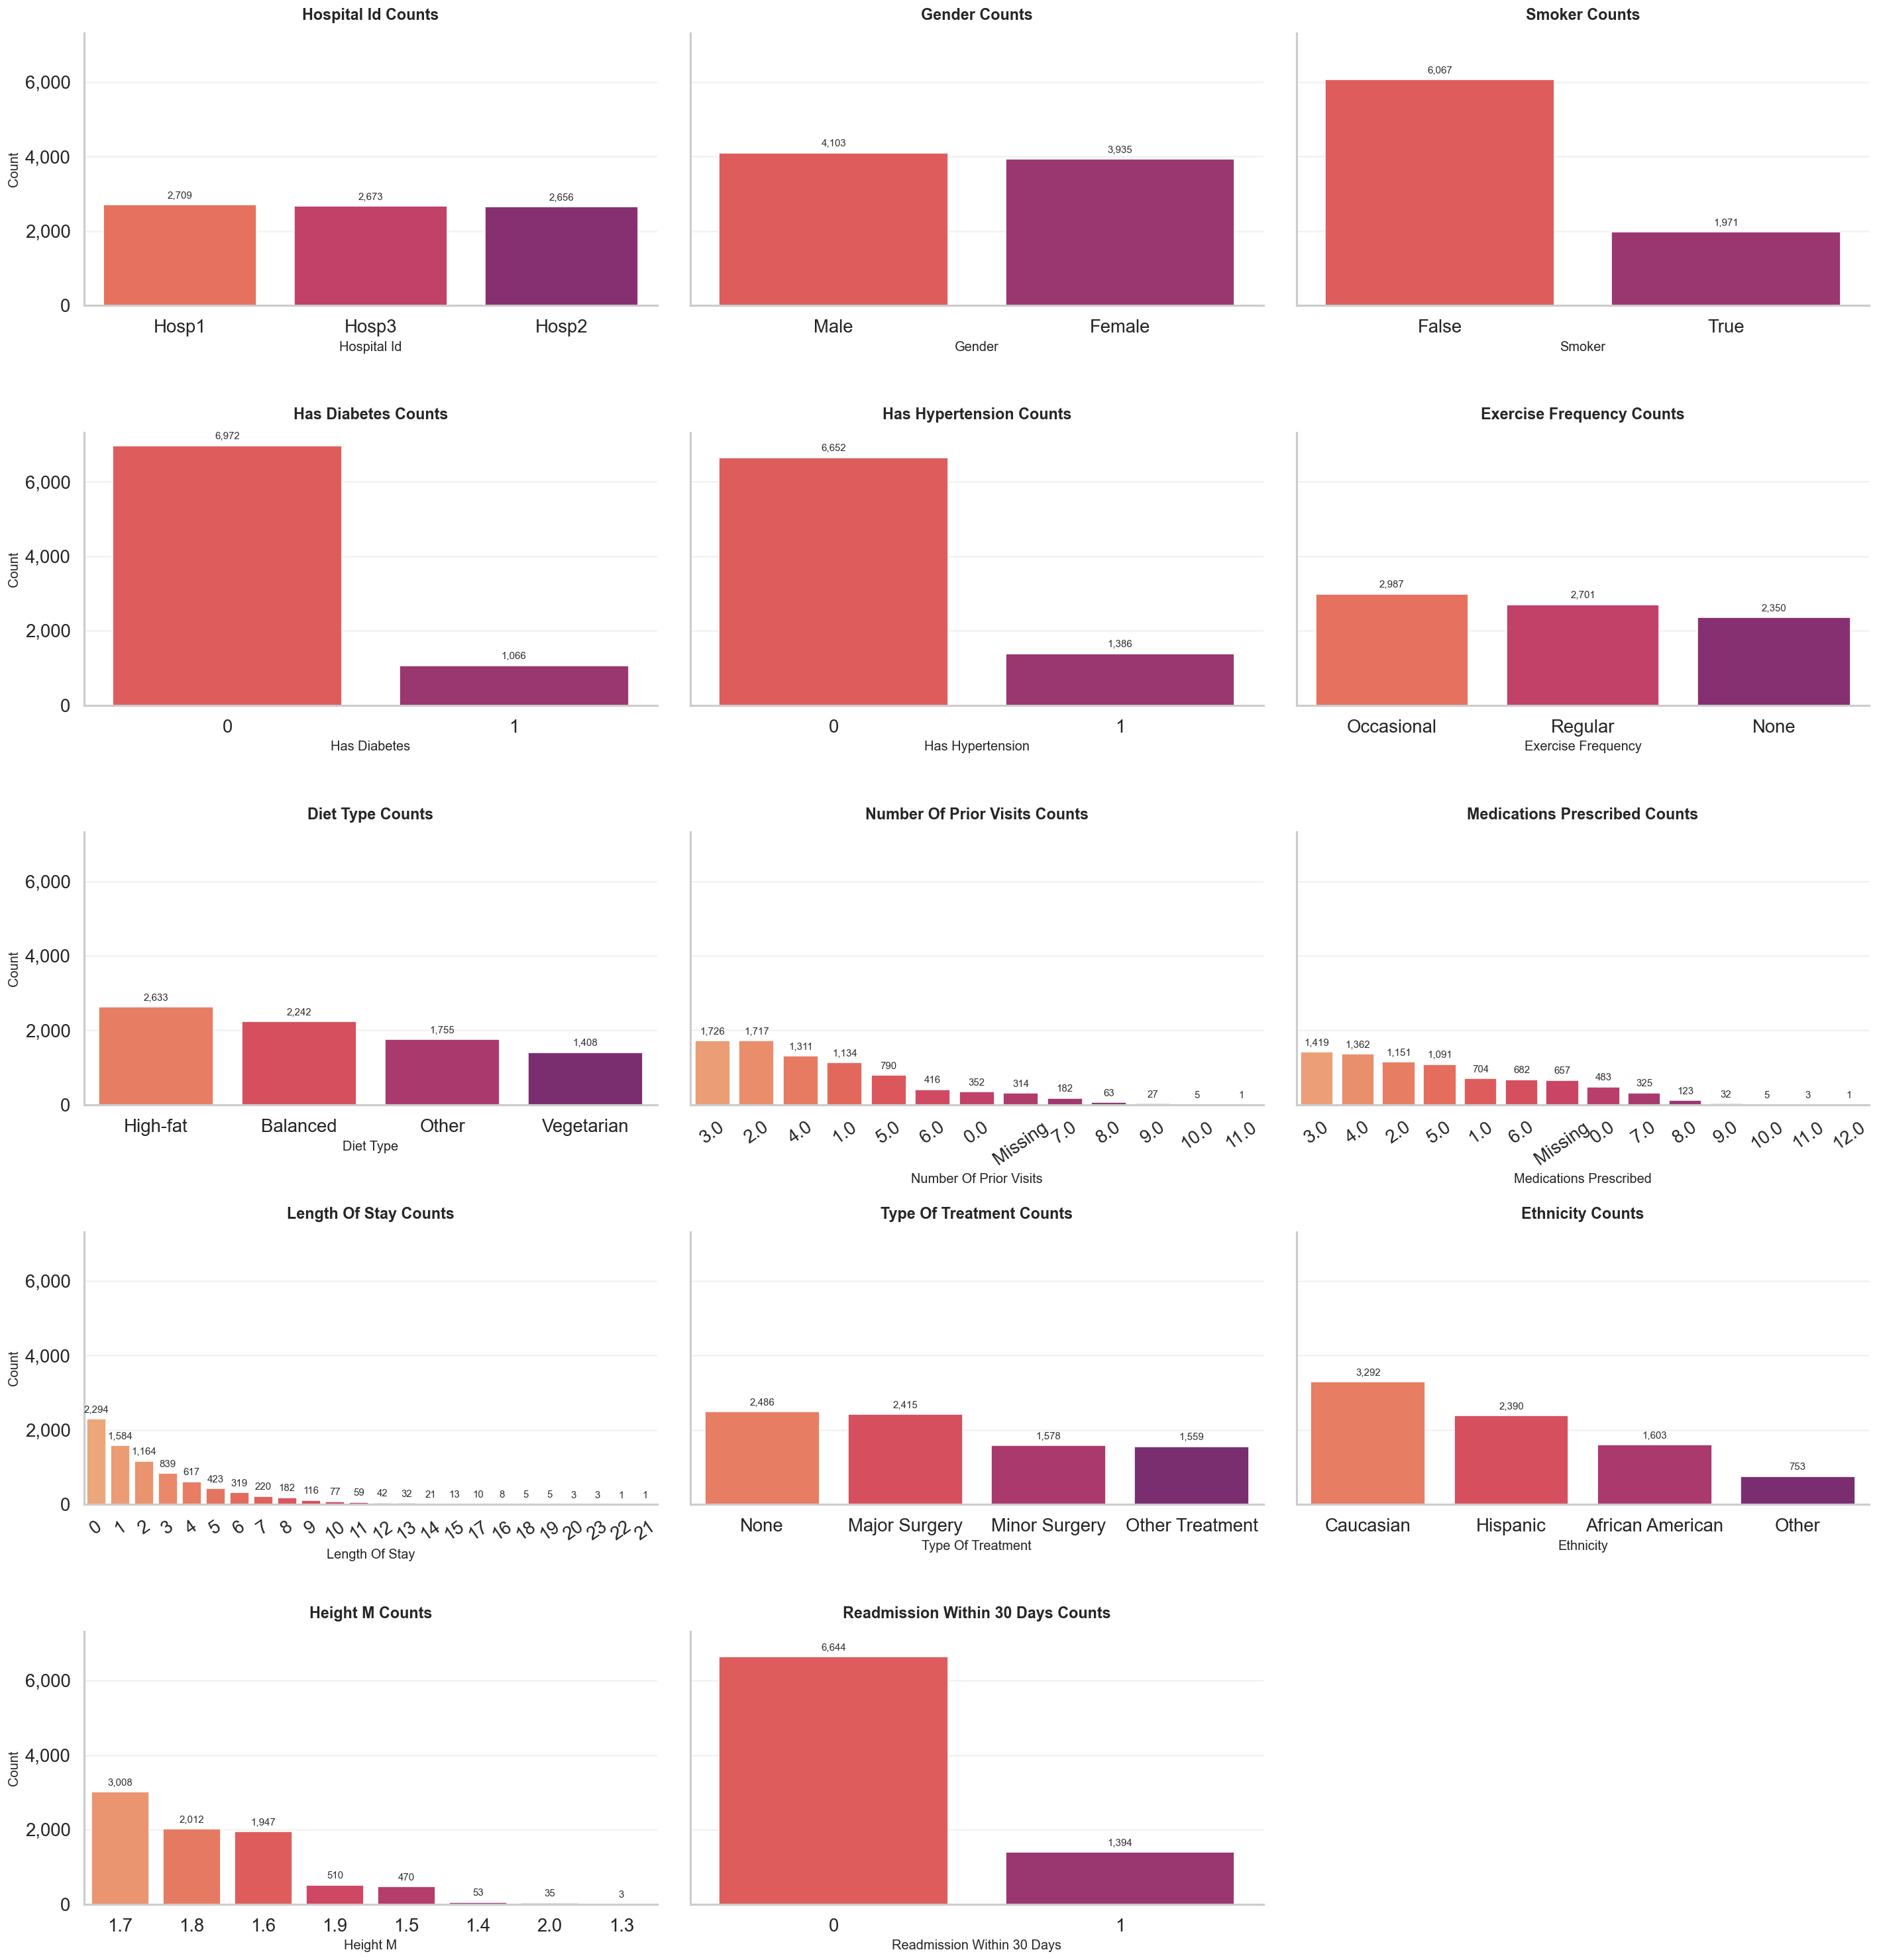

In [27]:
plot_grid(
    df=df_transformed,
    column_names=categories,
    plot_func=plot_barplot,
    palette="flare",
    n_plot_cols=3,
    sharey=True,
)

Categorical Distribution Notes:
- target class imbalanced
- medications prescribed and number of prior visits have a strong amount of missings (as well as 0 values)
- gender, hospital-id, both quite even distributions

(<Figure size 1920x1200 with 4 Axes>,
 array([<Axes: title={'center': 'Bmi Distribution'}, xlabel='Bmi', ylabel='Count'>,
        <Axes: title={'center': 'Weight Kg Distribution'}, xlabel='Weight Kg', ylabel='Count'>,
        <Axes: title={'center': 'Adjusted Weight Kg Distribution'}, xlabel='Adjusted Weight Kg', ylabel='Count'>,
        <Axes: title={'center': 'Age Distribution'}, xlabel='Age', ylabel='Count'>],
       dtype=object))

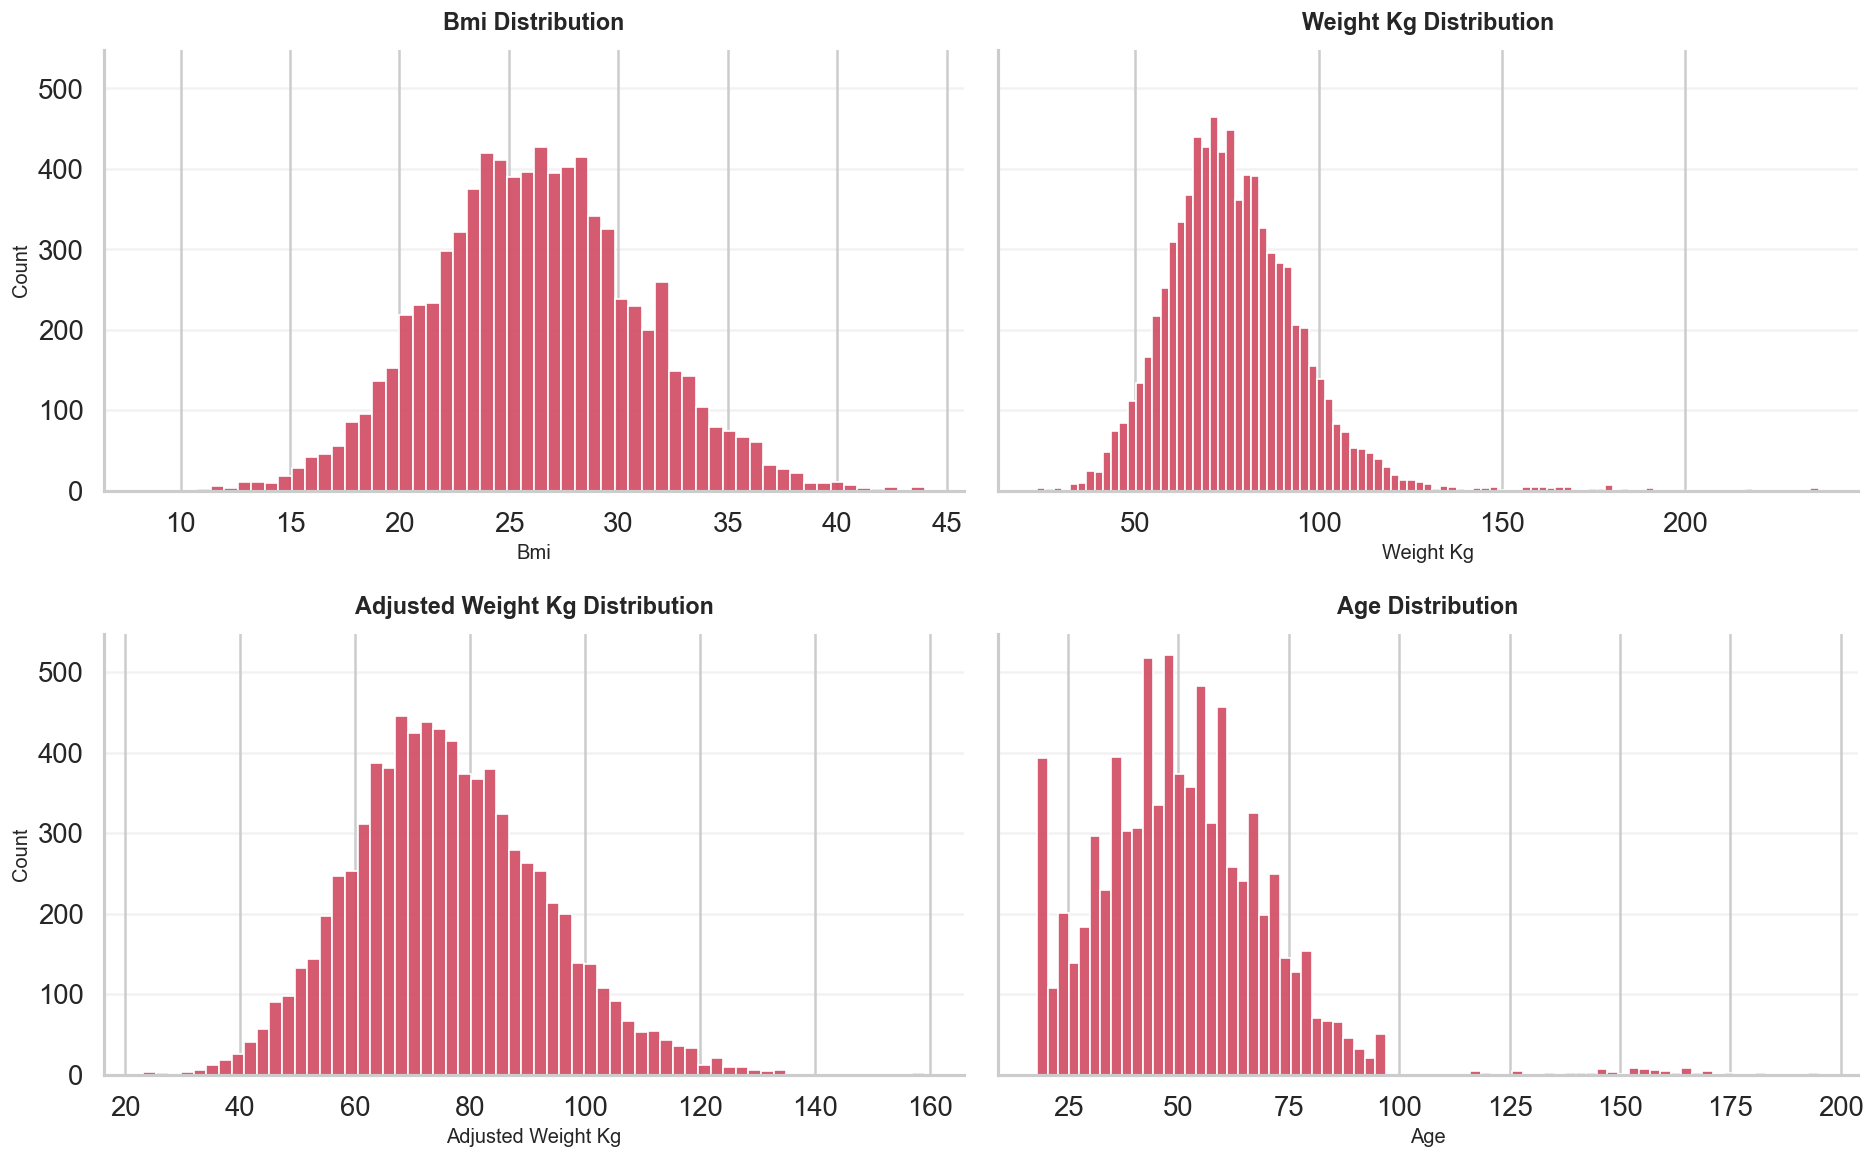

In [28]:
plot_grid(
    df=df_transformed,
    column_names=measures,
    plot_func=plot_histogram,
    n_plot_cols=2,
    sharey=True, 
    bins="auto",
    stat="count",
    kde=False,
    show_bin_counts=False,
)

Measure Distribution Notes:
- lots of outliers in age - ages above 100 should not be possible
- potentially similar with weight; will relook once outliers of age are checked

In [33]:
# age outlier checking
threshold = 3
age_z_scores = np.abs(stats.zscore(df_transformed["age"]))
age_outliers = np.where(age_z_scores > threshold)[0]
print(f"Identified {len(age_outliers)} age outliers at threshold {threshold}:")

display(df_transformed.loc[age_outliers, "age"])


Identified 80 age outliers at threshold 3:


122     158
136     167
253     126
535     147
547     120
       ... 
7251    136
7589    165
7814    195
7976    145
8027    156
Name: age, Length: 80, dtype: int64

In [34]:
df_transformed_2 = df_transformed.drop(index=age_outliers).reset_index(drop=True)

(<Figure size 1920x1200 with 4 Axes>,
 array([<Axes: title={'center': 'Bmi Distribution'}, xlabel='Bmi', ylabel='Count'>,
        <Axes: title={'center': 'Weight Kg Distribution'}, xlabel='Weight Kg', ylabel='Count'>,
        <Axes: title={'center': 'Adjusted Weight Kg Distribution'}, xlabel='Adjusted Weight Kg', ylabel='Count'>,
        <Axes: title={'center': 'Age Distribution'}, xlabel='Age', ylabel='Count'>],
       dtype=object))

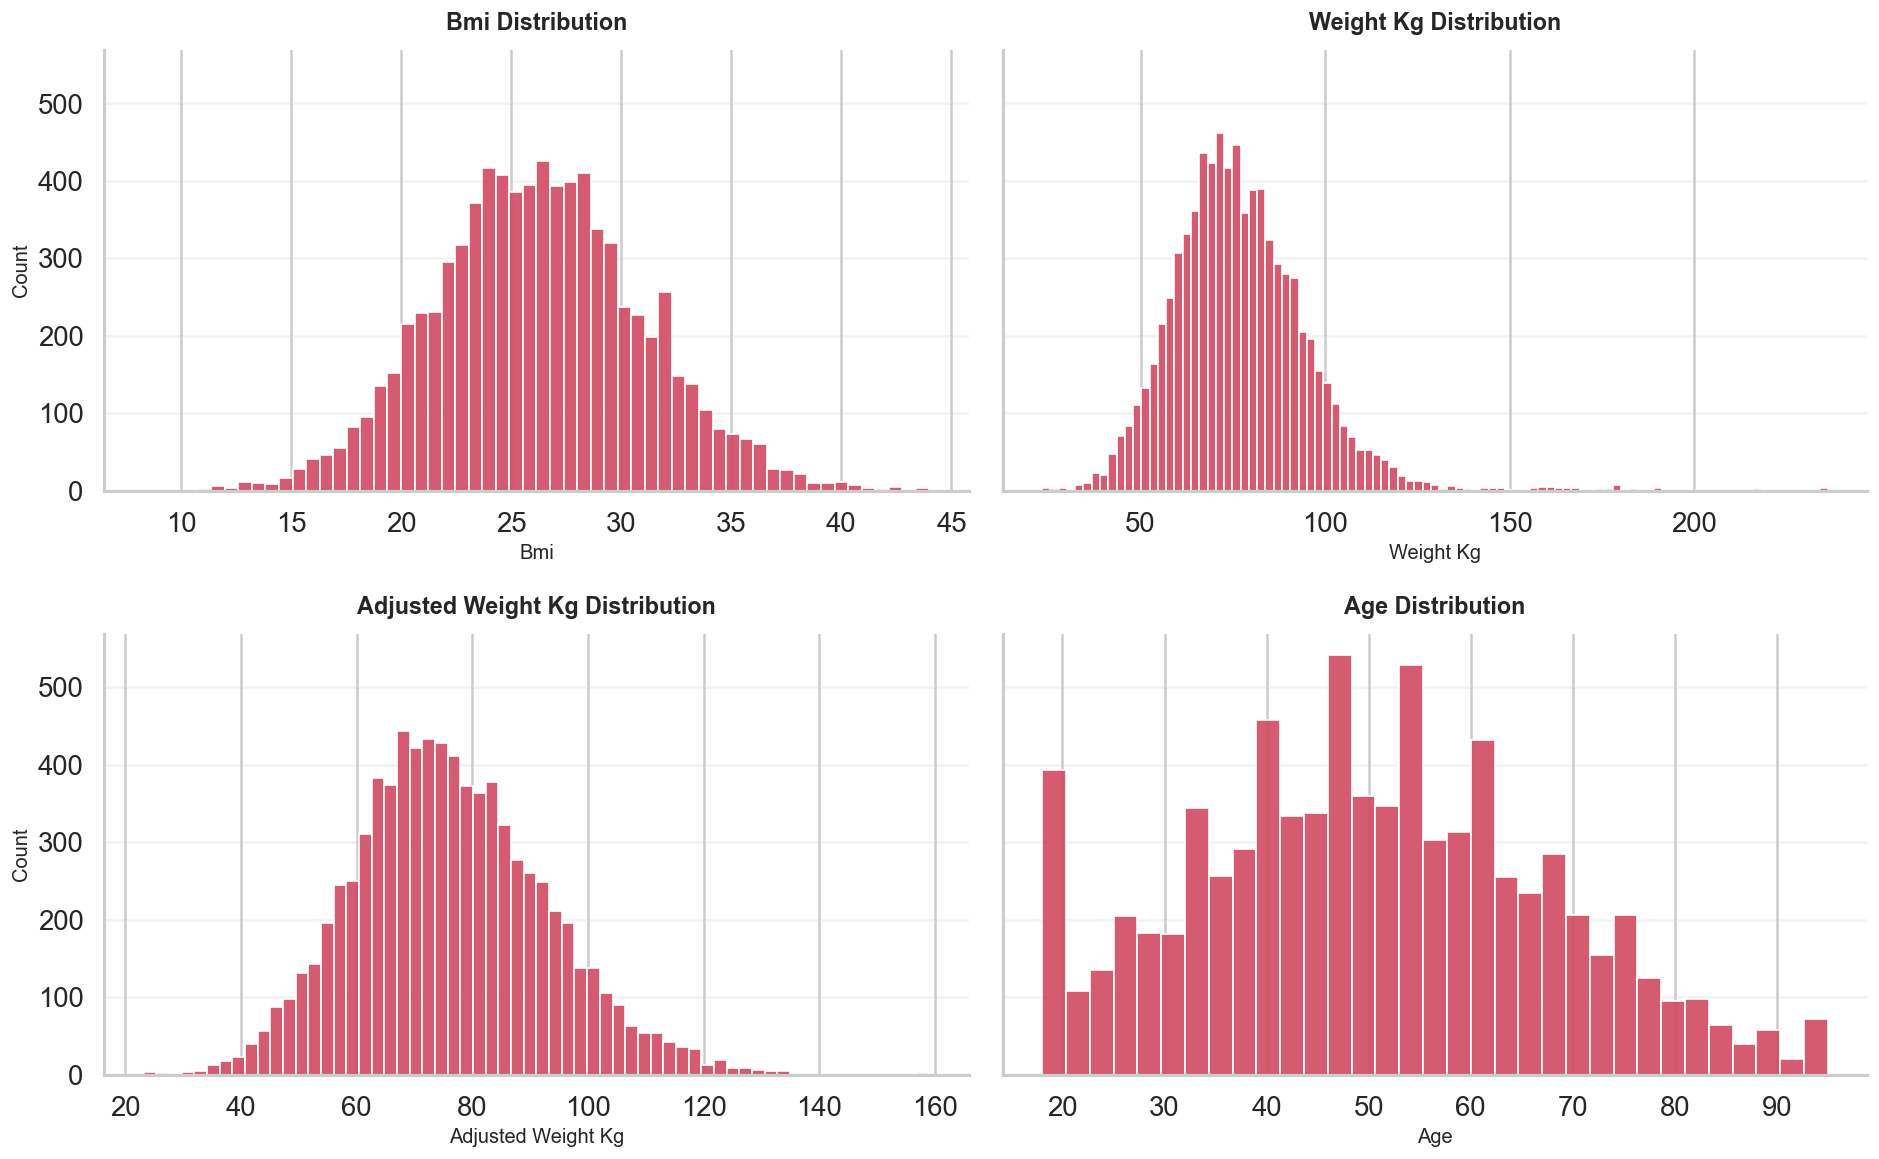

In [36]:
plot_grid(
    df=df_transformed_2,
    column_names=measures,
    plot_func=plot_histogram,
    n_plot_cols=2,
    sharey=True, 
    bins="auto",
    stat="count",
    kde=False,
    show_bin_counts=False,
)

age dsitribution fixed. some high weight values but those could be plausible, also adjusted weight looks normal as well as bmi distribution, so will leave weight as is for now.

In [38]:
df_final = df_transformed_2.copy()

In [39]:
display(df_final.info())

<class 'pandas.DataFrame'>
RangeIndex: 7958 entries, 0 to 7957
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  7958 non-null   int64  
 1   age                         7958 non-null   int64  
 2   gender                      7958 non-null   str    
 3   ethnicity                   7958 non-null   str    
 4   hospital_id                 7958 non-null   str    
 5   height_m                    7958 non-null   float64
 6   smoker                      7958 non-null   bool   
 7   bmi                         7958 non-null   float64
 8   weight_kg                   7958 non-null   float64
 9   adjusted_weight_kg          7958 non-null   float64
 10  has_diabetes                7958 non-null   int64  
 11  has_hypertension            7958 non-null   int64  
 12  exercise_frequency          7958 non-null   str    
 13  diet_type                   7958 non-null   

None

In [40]:
df_final.describe()

,patient_id,age,height_m,bmi,weight_kg,adjusted_weight_kg,has_diabetes,has_hypertension,number_of_prior_visits,medications_prescribed,length_of_stay,readmission_within_30_days
count,7.958000e+03,7958.000000,7958.000000,7958.000000,7958.000000,7958.000000,7958.000000,7958.000000,7646.000000,7308.000000,7958.000000,7958.000000
mean,1.005018e+06,50.108696,1.700968,26.259286,77.151715,76.265424,0.131943,0.171274,3.043552,3.510536,2.543101,0.173159
std,2.890074e+03,17.296195,0.104121,4.745497,18.946807,16.660954,0.338450,0.376772,1.739568,1.956772,2.969636,0.378409
min,1.000000e+06,18.000000,1.300000,8.300000,23.300000,23.126324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.002518e+06,38.000000,1.600000,23.100000,64.800000,64.727639,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,1.005022e+06,50.000000,1.700000,26.200000,75.400000,75.131618,0.000000,0.000000,3.000000,3.000000,2.000000,0.000000
75%,1.007536e+06,62.000000,1.800000,29.300000,87.300000,86.863488,0.000000,0.000000,4.000000,5.000000,4.000000,0.000000
max,1.009999e+06,95.000000,2.000000,44.000000,236.300000,159.051116,1.000000,1.000000,11.000000,12.000000,23.000000,1.000000


## **4. Bivariate Analysis**
- Bivariate visualizations of each variable vs the response variable and any other “interesting” pairs of variables. Can be done with Tableau or Python
- Annotate any significant observations


(<Figure size 1920x1800 with 6 Axes>,
 array([<Axes: title={'center': 'smoker by readmission_within_30_days'}, xlabel='smoker', ylabel='count'>,
        <Axes: title={'center': 'has_diabetes by readmission_within_30_days'}, xlabel='has_diabetes', ylabel='count'>,
        <Axes: title={'center': 'exercise_frequency by readmission_within_30_days'}, xlabel='exercise_frequency', ylabel='count'>,
        <Axes: title={'center': 'diet_type by readmission_within_30_days'}, xlabel='diet_type', ylabel='count'>,
        <Axes: title={'center': 'gender by readmission_within_30_days'}, xlabel='gender', ylabel='count'>,
        <Axes: title={'center': 'has_hypertension by readmission_within_30_days'}, xlabel='has_hypertension', ylabel='count'>],
       dtype=object))

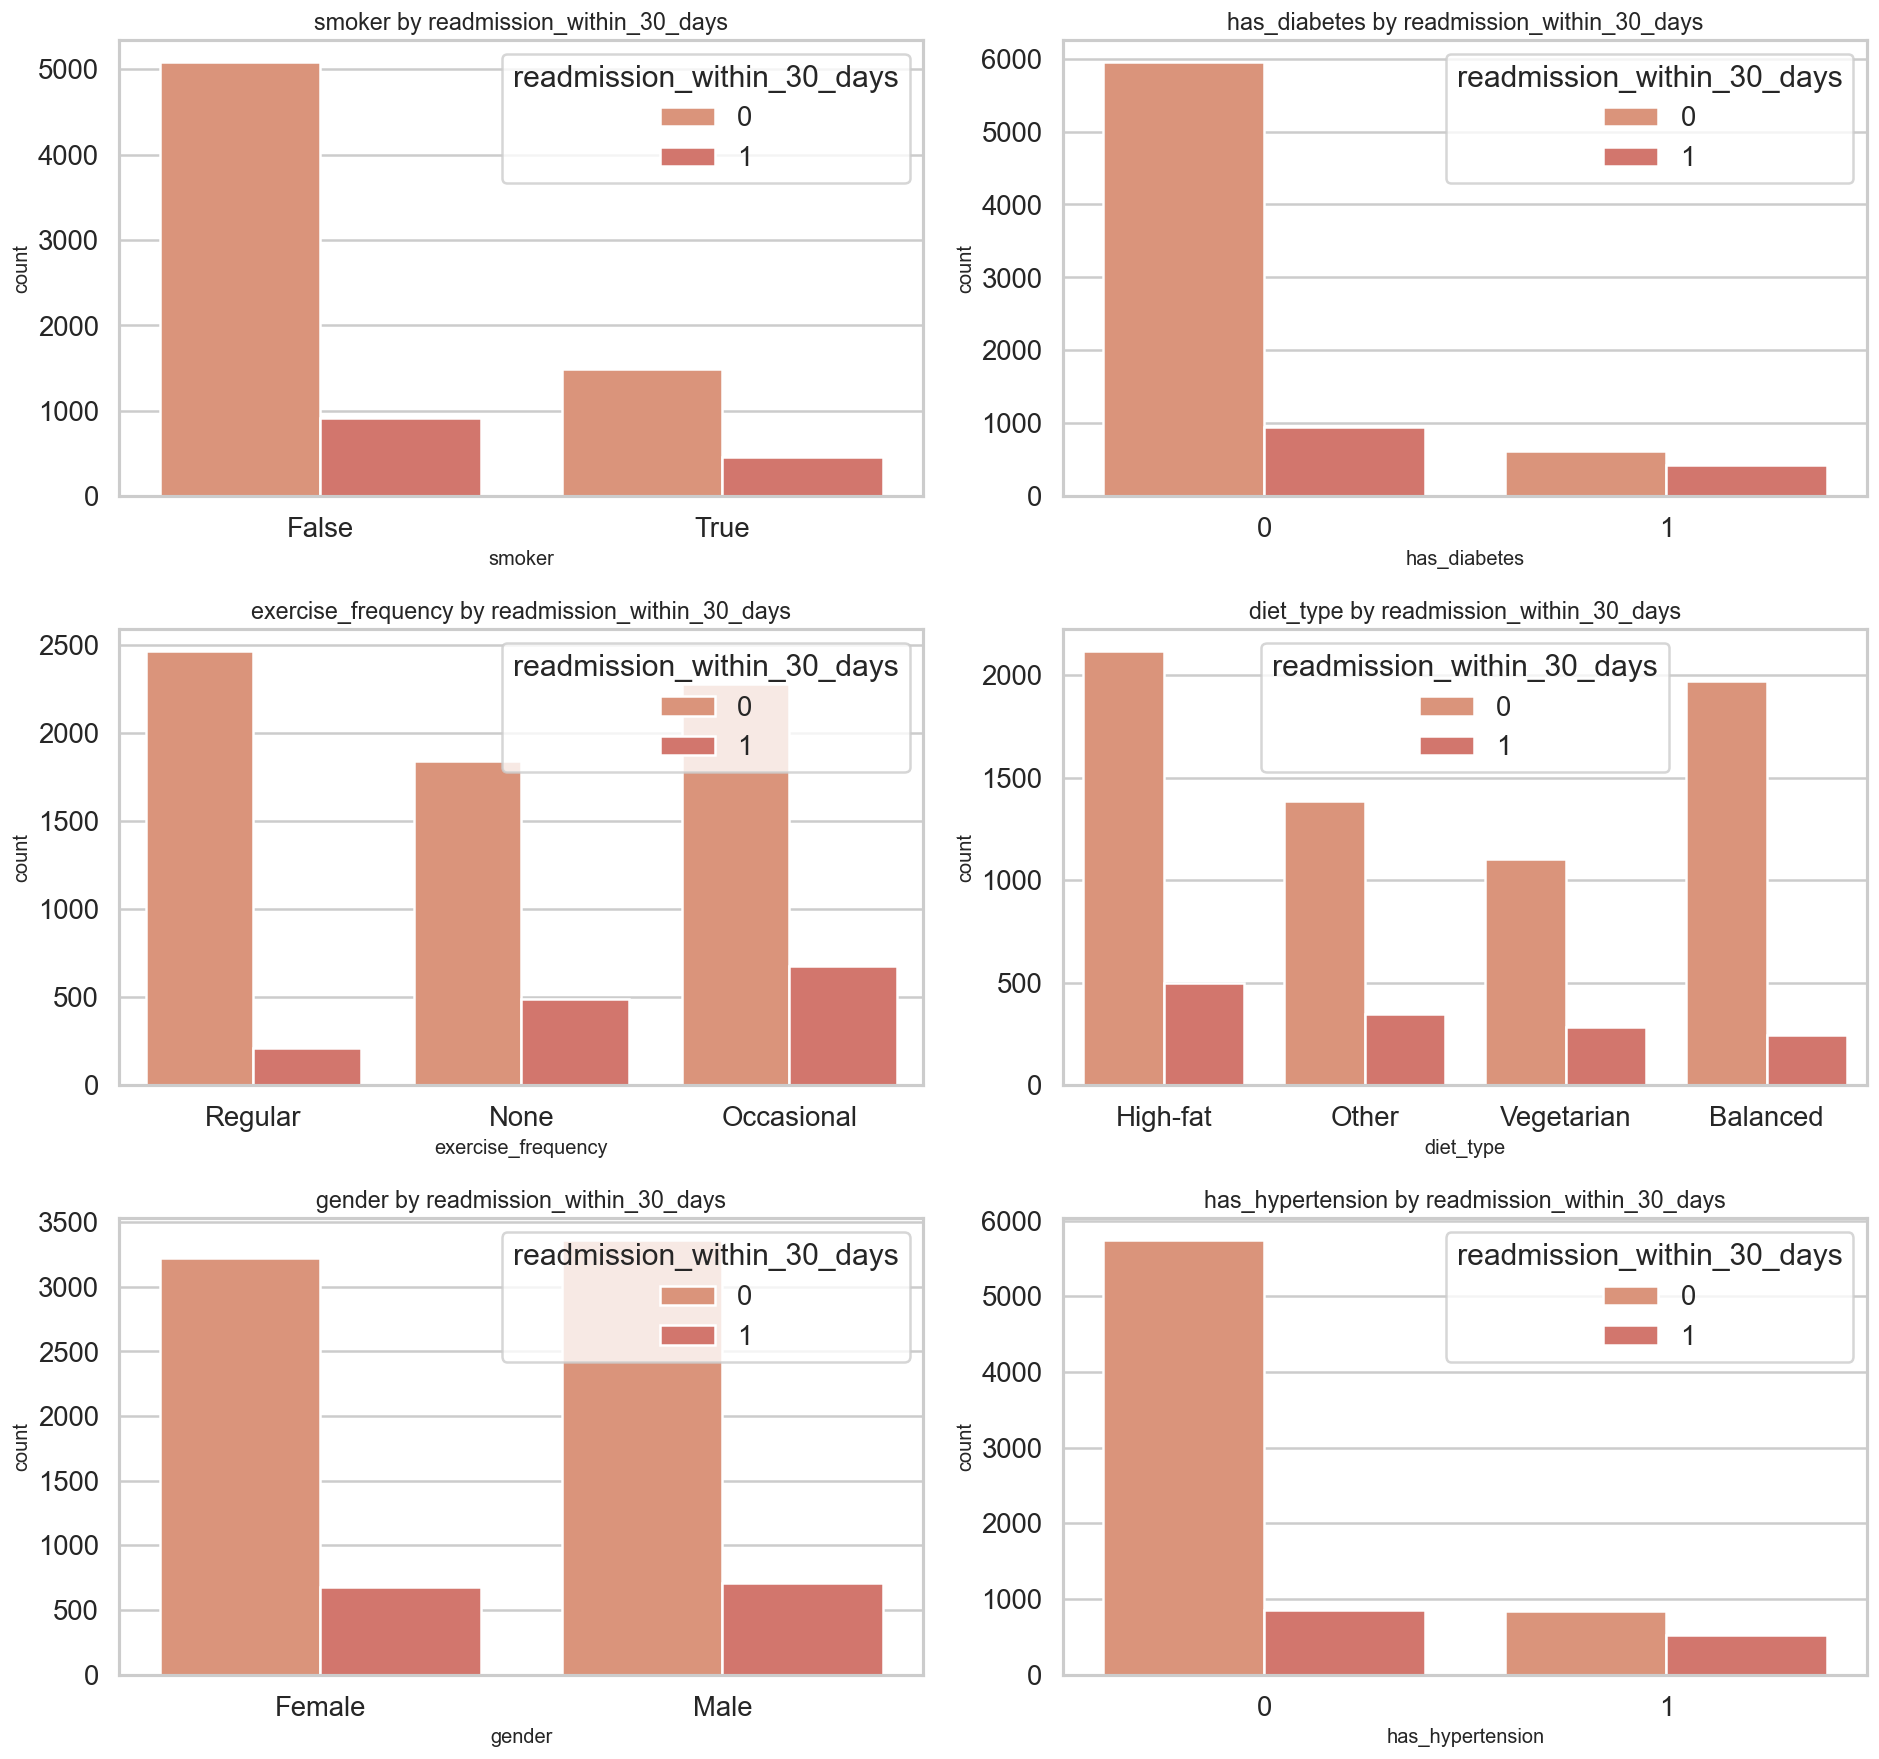

In [42]:
plot_categorical_x_categorical_grid(
    df=df_final,
    base_cat_col="readmission_within_30_days",  
    category_cols=["smoker", "has_diabetes", "exercise_frequency", "diet_type", "gender", "has_hypertension"],
    plot_func=sns.countplot,
    n_plot_cols=2,
    figsize_scale=(8, 5),
)

(<Figure size 1920x1200 with 4 Axes>,
 array([<Axes: title={'center': 'age vs bmi'}, xlabel='age', ylabel='bmi'>,
        <Axes: title={'center': 'weight_kg vs bmi'}, xlabel='weight_kg', ylabel='bmi'>,
        <Axes: title={'center': 'adjusted_weight_kg vs bmi'}, xlabel='adjusted_weight_kg', ylabel='bmi'>,
        <Axes: title={'center': 'length_of_stay vs bmi'}, xlabel='length_of_stay', ylabel='bmi'>],
       dtype=object))

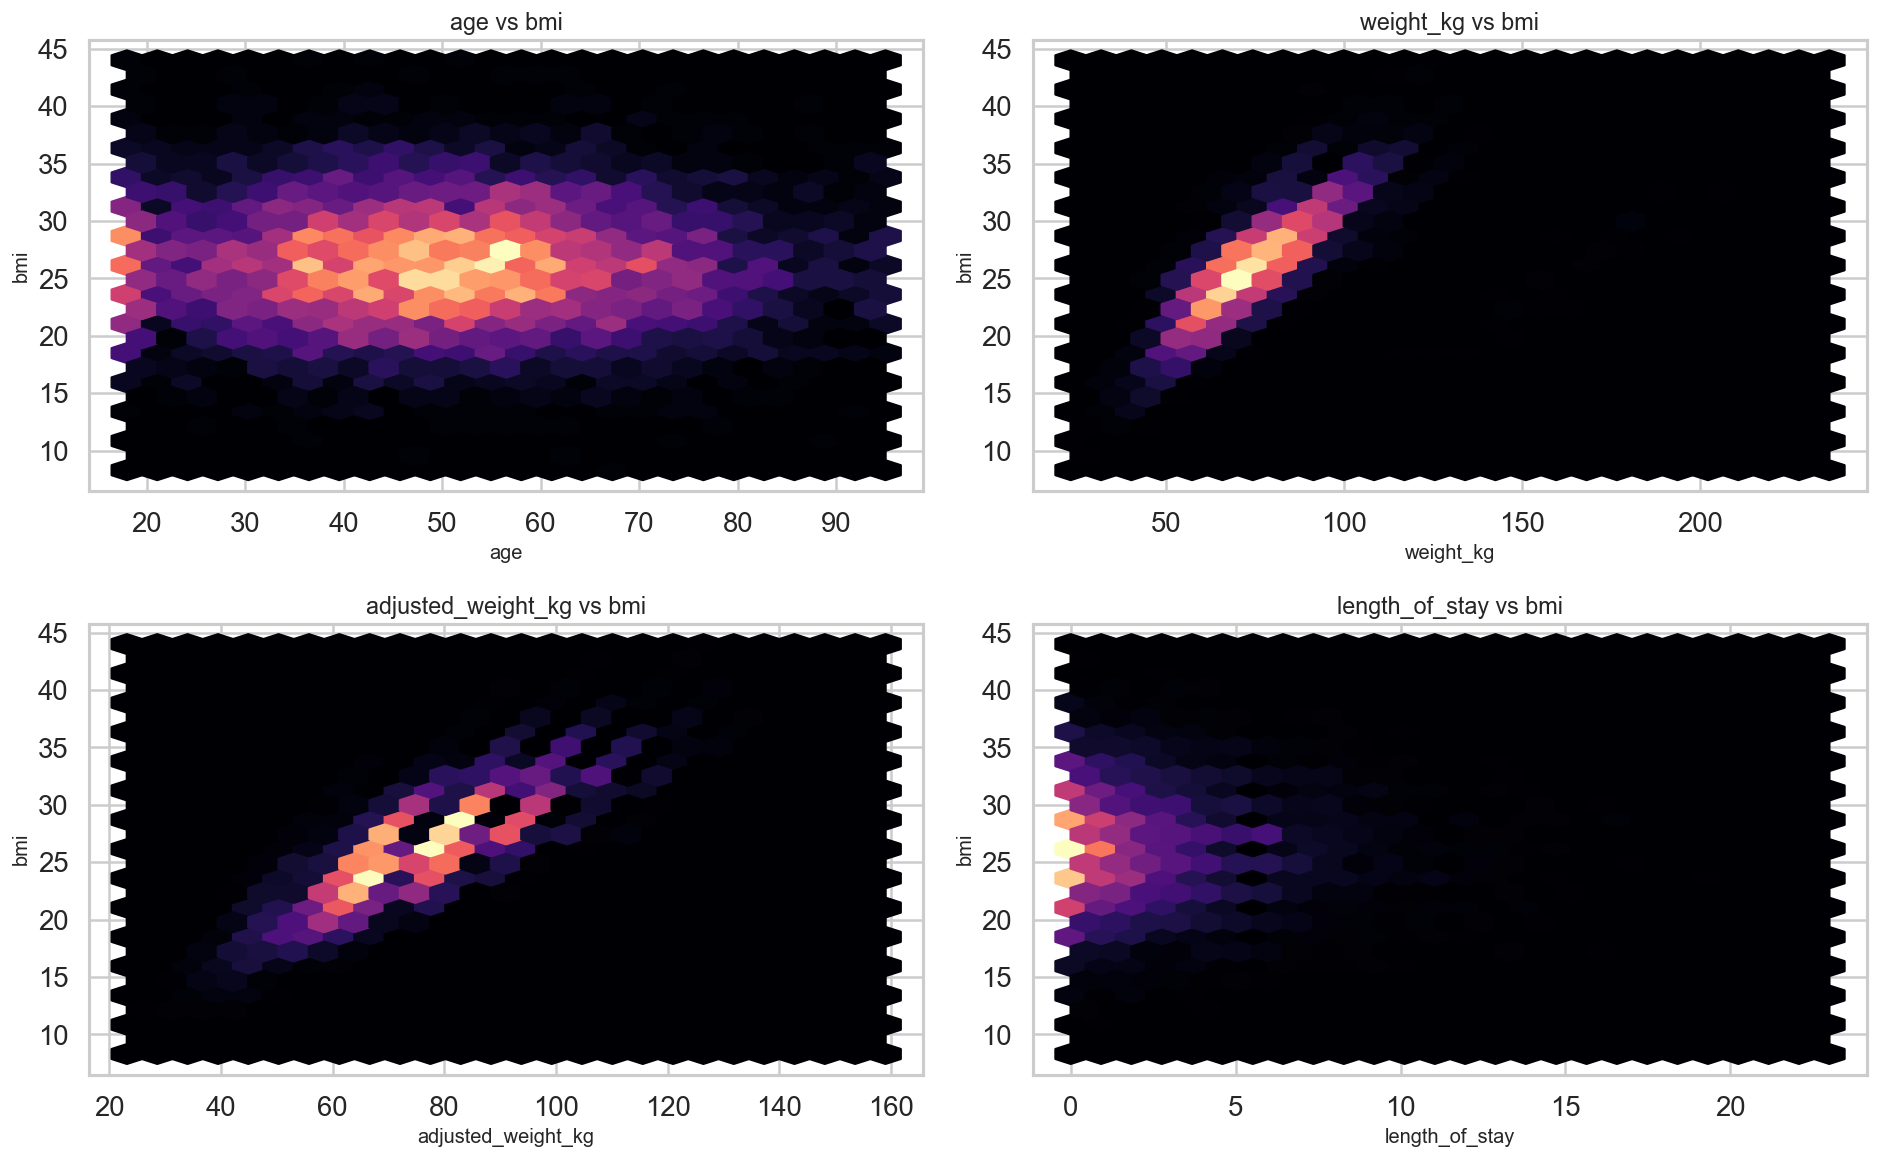

In [43]:
plot_numeric_x_numeric_grid(
    df=df_final,
    base_numeric_col="bmi",
    numeric_cols=["age", "weight_kg", "adjusted_weight_kg", "length_of_stay"],
    plot_func='hexbin',
    n_plot_cols=2,
    gridsize=25,
    cmap="magma",
)

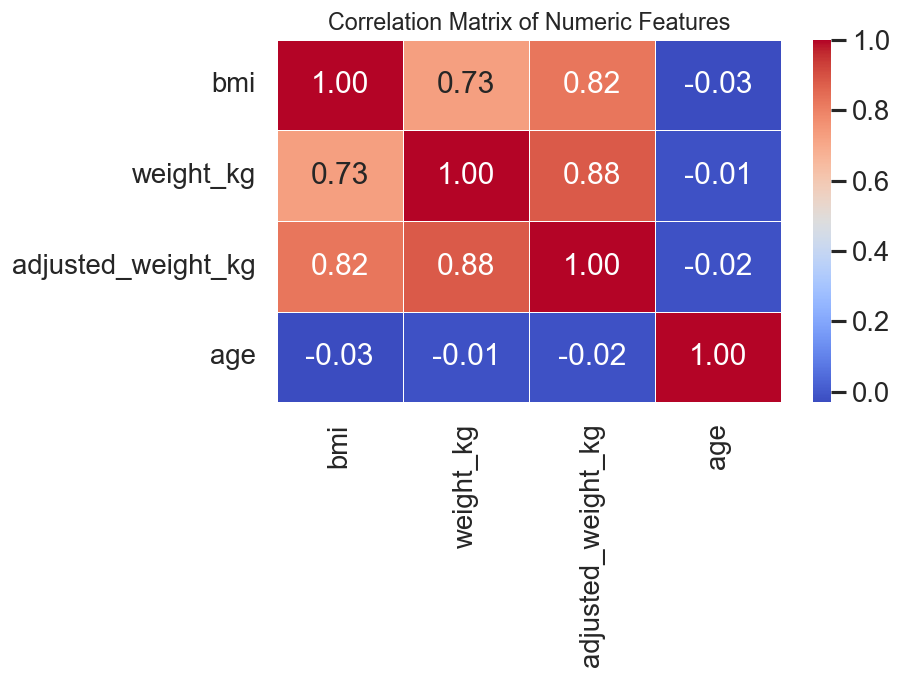

In [44]:
# correlation matrix

numeric_df = df_final[measures]

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()


(<Figure size 1920x2400 with 7 Axes>,
 array([<Axes: title={'center': 'bmi by gender'}, xlabel='gender', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by smoker'}, xlabel='smoker', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by has_diabetes'}, xlabel='has_diabetes', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by exercise_frequency'}, xlabel='exercise_frequency', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by diet_type'}, xlabel='diet_type', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by hospital_id'}, xlabel='hospital_id', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by type_of_treatment'}, xlabel='type_of_treatment', ylabel='bmi'>],
       dtype=object))

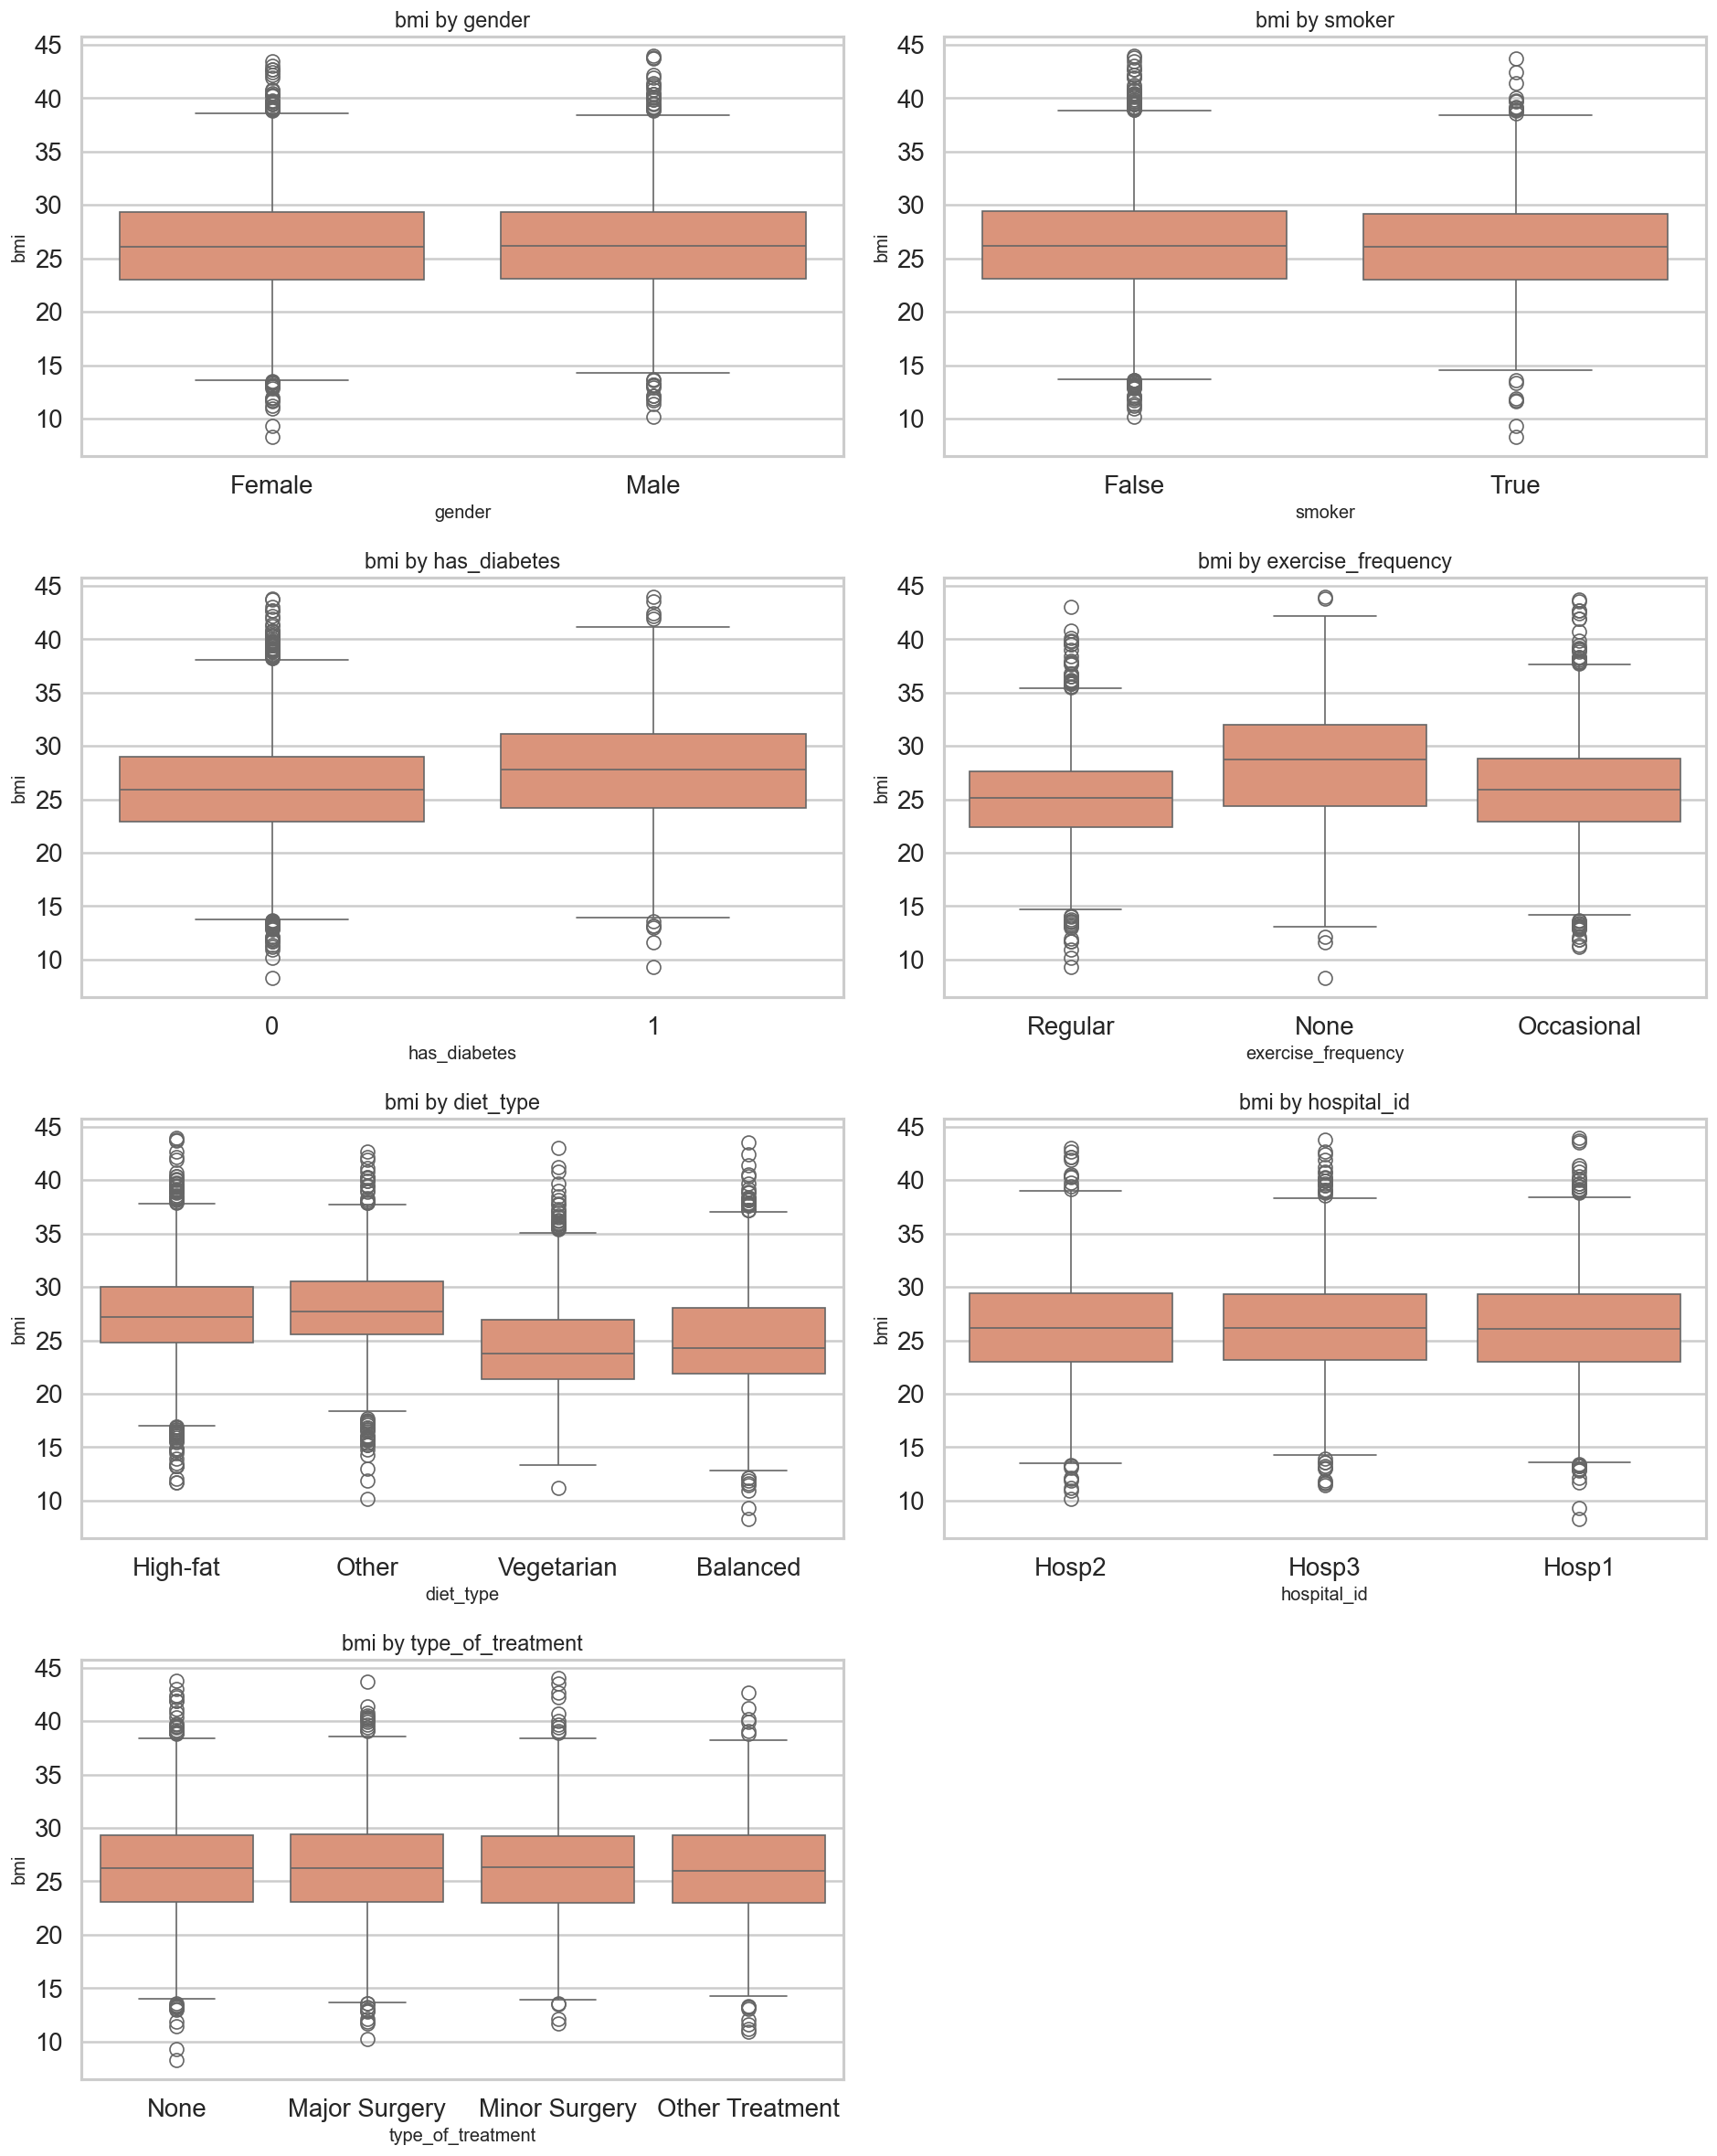

In [45]:
# BMI vs categorical features
plot_numeric_x_across_categories_grid(
    df=df_final,
    numeric_col="bmi",
    category_cols=["gender", "smoker", "has_diabetes", "exercise_frequency", "diet_type", "hospital_id", "type_of_treatment"],
    plot_func=sns.boxplot,
    n_plot_cols=2,
    figsize_scale=(8, 5),
)


(<Figure size 2160x1920 with 10 Axes>,
 array([<Axes: title={'center': 'age by readmission_within_30_days'}, xlabel='readmission_within_30_days', ylabel='age'>,
        <Axes: title={'center': 'height_m by readmission_within_30_days'}, xlabel='readmission_within_30_days', ylabel='height_m'>,
        <Axes: title={'center': 'bmi by readmission_within_30_days'}, xlabel='readmission_within_30_days', ylabel='bmi'>,
        <Axes: title={'center': 'weight_kg by readmission_within_30_days'}, xlabel='readmission_within_30_days', ylabel='weight_kg'>,
        <Axes: title={'center': 'adjusted_weight_kg by readmission_within_30_days'}, xlabel='readmission_within_30_days', ylabel='adjusted_weight_kg'>,
        <Axes: title={'center': 'has_diabetes by readmission_within_30_days'}, xlabel='readmission_within_30_days', ylabel='has_diabetes'>,
        <Axes: title={'center': 'has_hypertension by readmission_within_30_days'}, xlabel='readmission_within_30_days', ylabel='has_hypertension'>,
        <Ax

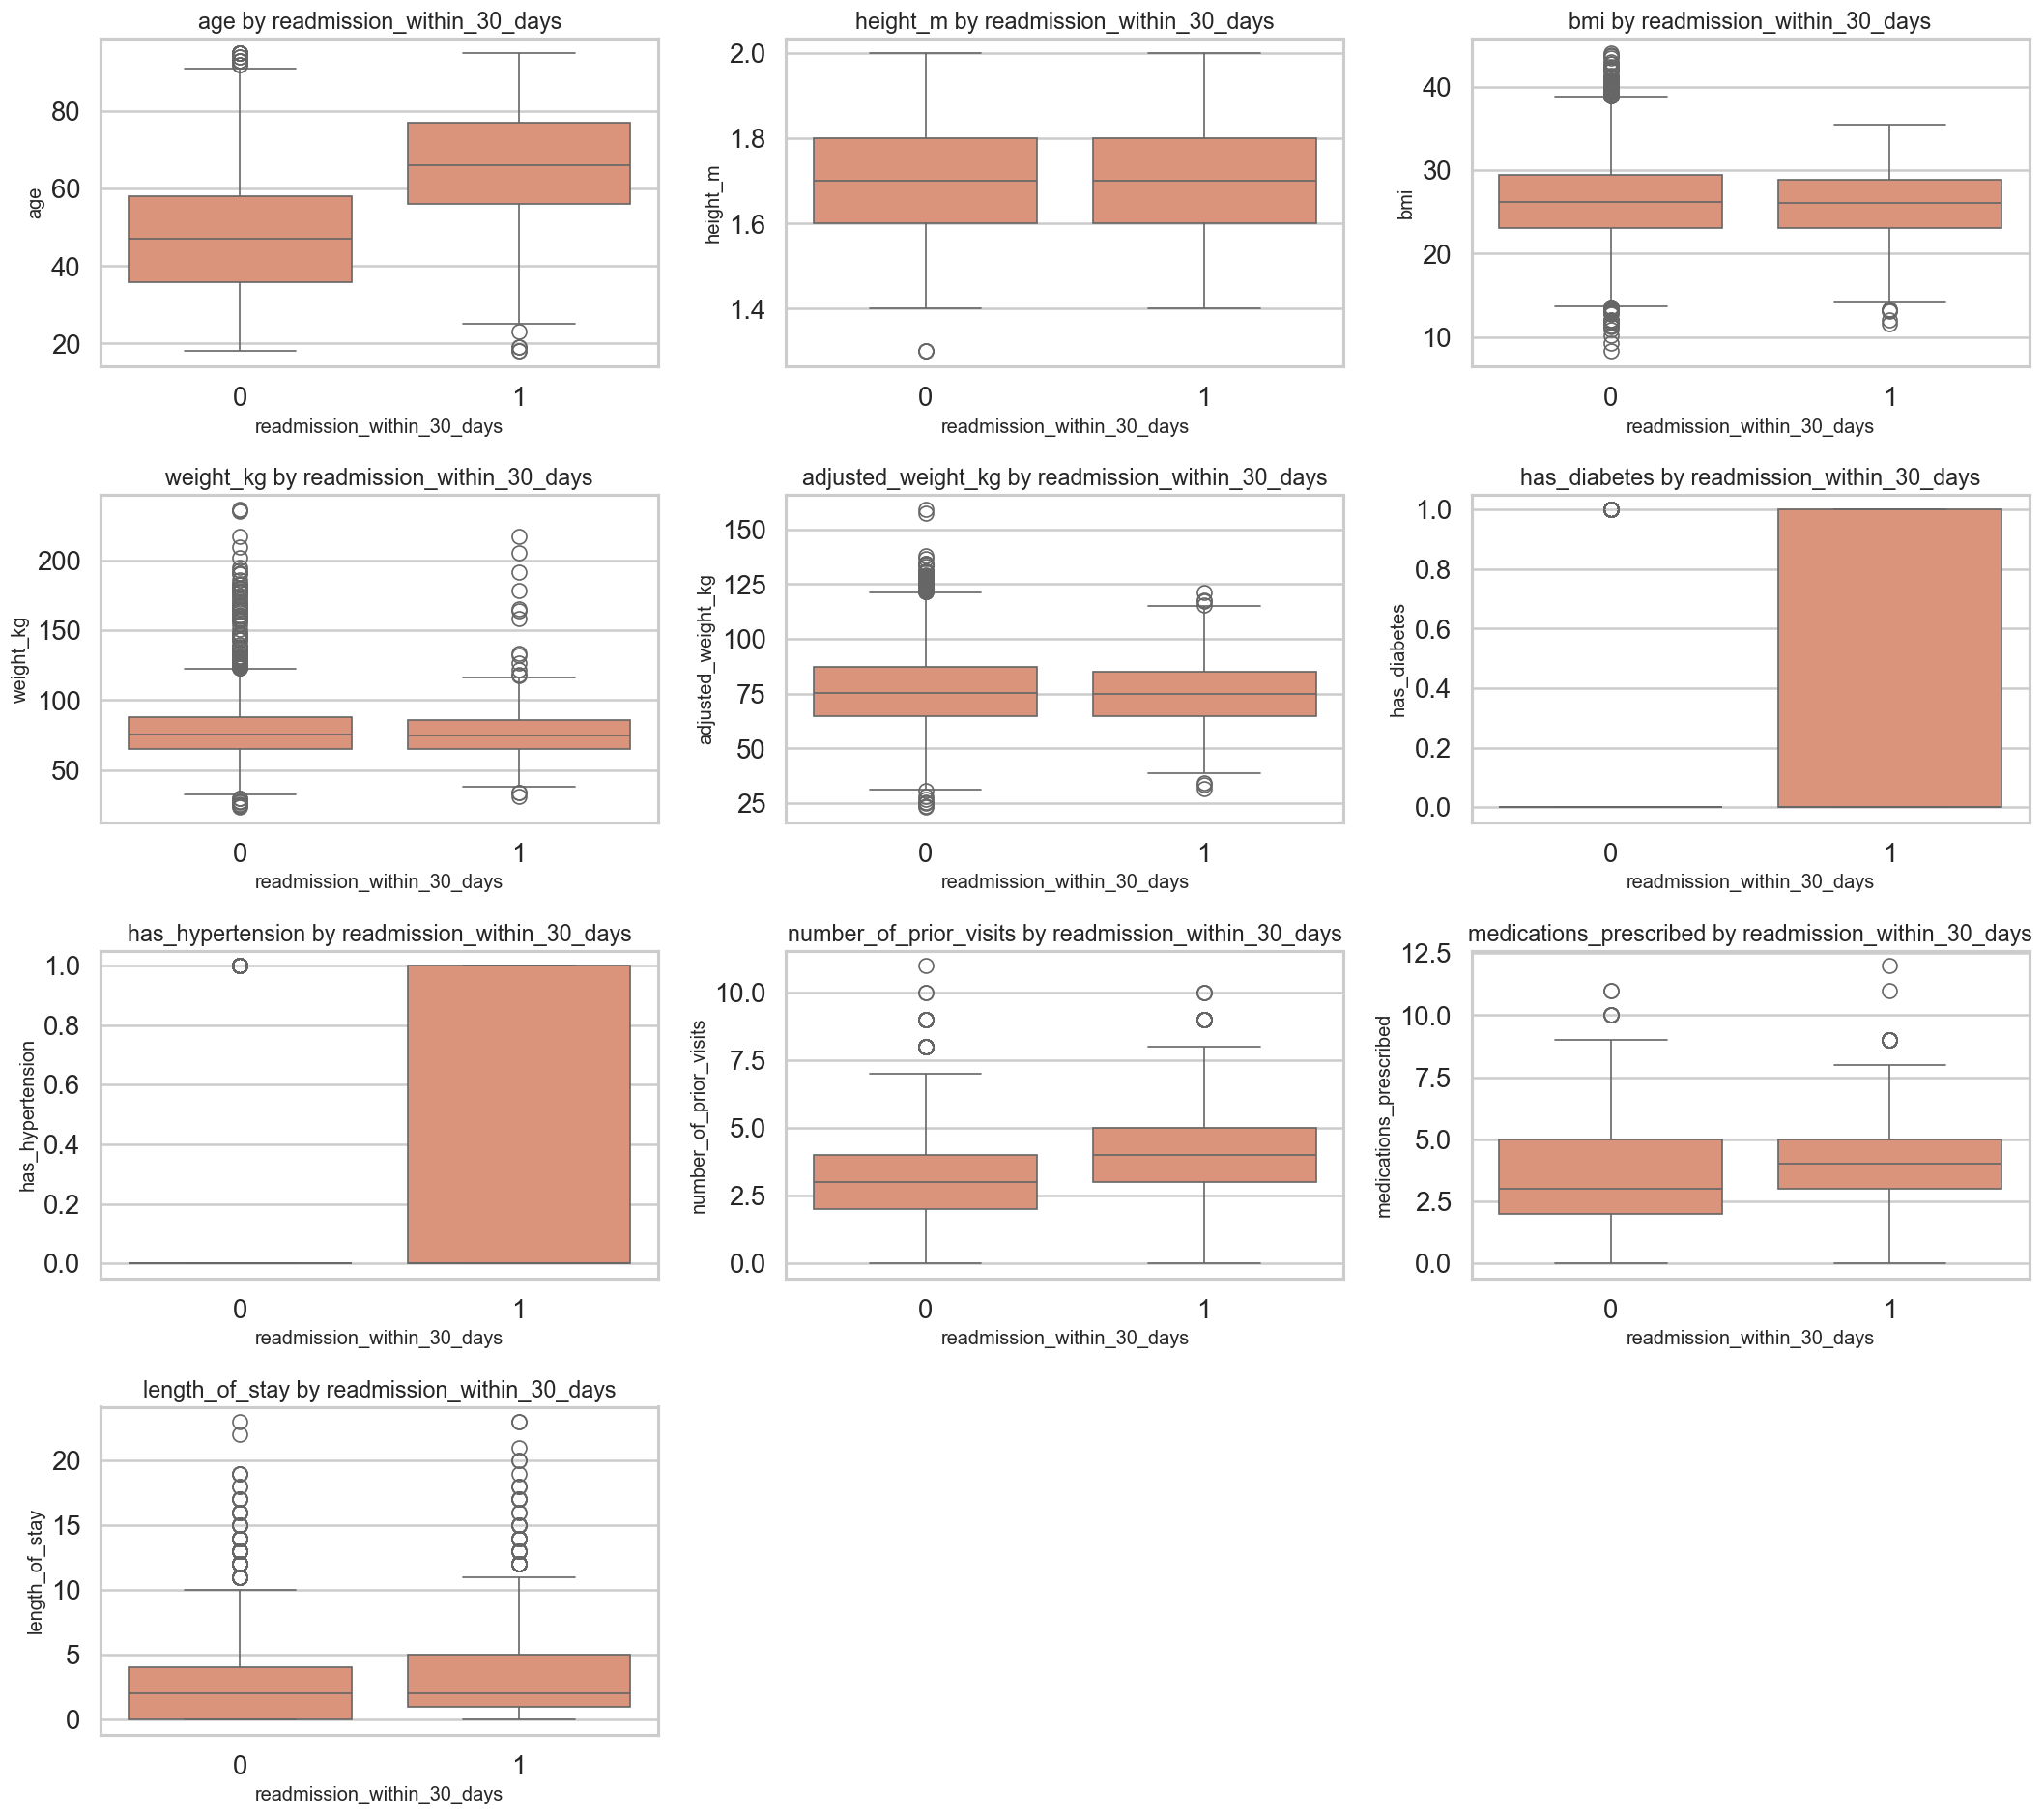

In [46]:
# Plot all numeric columns as boxplots split by target
plot_all_numeric_by_base_category_grid(
    df=df_final,
    base_cat_col="readmission_within_30_days",
    plot_func=sns.boxplot,
    n_plot_cols=3,
    figsize_scale=(6, 4),
)

In [47]:
df_final.duplicated().sum()

np.int64(0)

In [48]:
df_final.to_csv("../data/processed/healthcare_readmissions_dataset_train_processed.csv", index=False)